### Differences between VGP, SVGP, CMOGP, sCMOGP, sCMOGP with exact target. 
Sometimes, CMOGP does as well as the VGPs (or better, like this example), but it is quite possible to get really bad results too.

In [1]:
import gpflow as gpf
import tensorflow as tf
import numpy as np
import sys
sys.path.append("../..")
from gpflow.models.training_mixins import InternalDataTrainingLossMixin
import matplotlib.pyplot as plt
from atlikelihood import TransferLikelihood

from gpflow.covariances.dispatch import Kuf, Kuu
from gpflow.utilities import to_default_float, assert_params_false, add_likelihood_noise_cov
from gpflow.config import default_jitter, default_float
from gpflow.utilities import to_default_float
from gpflow.models.util import InducingPointsLike, data_input_to_tensor, inducingpoint_wrapper
from gpflow.inducing_variables import InducingPoints
from typing import NamedTuple


from atmodel import ConditionalMOGP, SparseCMOGP
from atlikelihood import TransferLikelihood

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()


2026-06-10 18:26:28.861011: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-10 18:26:28.862687: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-10 18:26:28.950635: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-10 18:26:28.954416: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-10 18:26:31.269594: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

[  0  10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170
 180 190]


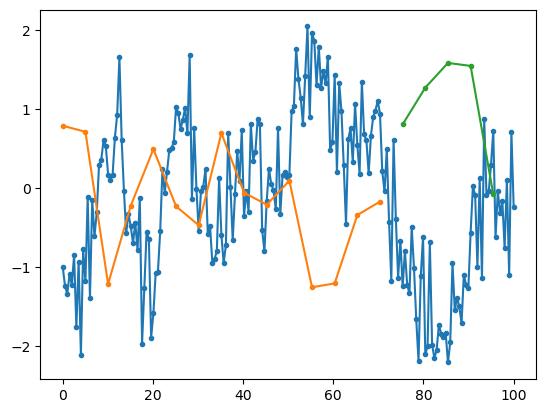

In [2]:
k = gpf.kernels.RBF(lengthscales=5, variance=1) #+ gpf.kernels.Linear(0.001)
Xall = np.linspace(0, 100, 200)
Yall  = np.random.multivariate_normal(np.zeros_like(Xall), k(Xall.reshape(-1, 1)))
ind_1 = np.arange(0, 200, 1)
ind_2 = np.arange(0, 200, 10)
ind_1 = ind_1
ind_2 = ind_2 
print(ind_2)
TEST_INDEX = int(0.75*len(ind_2))
ind_train, ind_test = ind_2[:TEST_INDEX], ind_2[TEST_INDEX:]
X1, y1 = Xall[ind_1], Yall[ind_1]
X2, y2 = Xall[ind_train], Yall[ind_train]
X2 = X2 - X2[0]
scalar = -1
y2 = scalar * y1 # np.roll(y2, 5)
y2 = y2[ind_train]
Xtest, ytest = Xall[ind_test], Yall[ind_test]
ytest = scalar * ytest.reshape(-1, 1) + np.random.normal(0, 0.5, len(Xtest)).reshape(-1, 1)

y1 = y1.reshape(-1, 1) + np.random.normal(0, 0.5, len(X1)).reshape(-1, 1)
y2 = y2.reshape(-1, 1) + np.random.normal(0, 0.5, len(X2)).reshape(-1, 1) 
X1 = X1.reshape(-1, 1)
X2 = X2.reshape(-1, 1)
y2 = y2 
plt.plot(X1, y1, marker=".")
plt.plot(X2, y2, marker=".")
plt.plot(Xtest, ytest, marker=".")
X = np.vstack((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
y = np.vstack((np.hstack((y1, np.zeros_like(y1))), np.hstack((y2, np.ones_like(y2)))))
plt.show()
X = tf.cast(X, np.float64)
y = tf.cast(y, np.float64)

In [3]:
# Experiment params
nIV = 50
halfIV = int(nIV/2)
shuffle = np.random.permutation(np.arange(nIV))

### CMOGP

╒════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                                               │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value   │
╞════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ ConditionalMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ ConditionalMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ ConditionalMOGP.ke

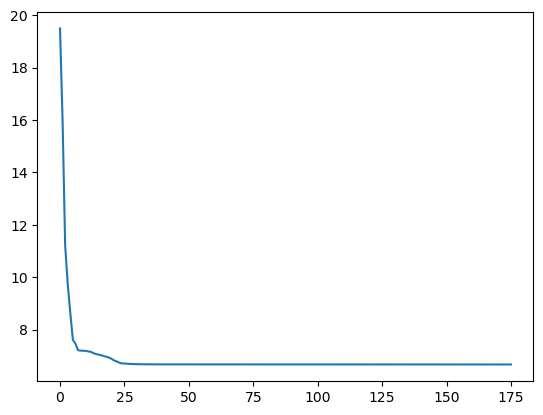

╒════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═══════════════════════════════════╕
│ name                                               │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                             │
╞════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═══════════════════════════════════╡
│ ConditionalMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.0006076341051045339             │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────────────────────────────┤
│ ConditionalMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 2007.19052                        │
├───

In [4]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg
m = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True)
#gpf.set_trainable(m.likelihood.source.variance, False)

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)

TensorShape([215, 200])
TensorShape([215, 5])


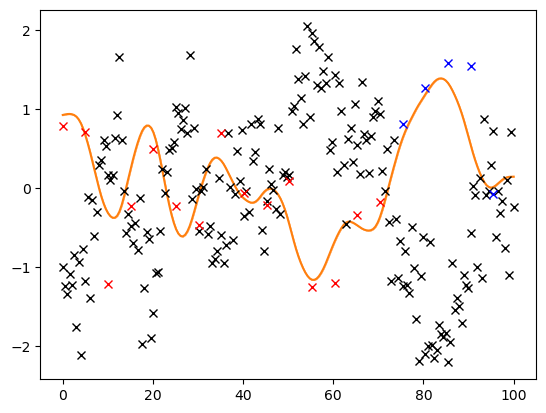

0.221124179150606

In [5]:
from sklearn.metrics import mean_squared_error
Xall = Xall.reshape(-1, 1)
Xtst = Xtest.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
plt.plot(Xall, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.show()

cmogp_mse = mean_squared_error(ytest, fmean_tst)
cmogp_mse

# sparse CMOGP with approximate target
(that is, Kbb is approximated via the inducing variables too, so the covariance of the objective is $Q_{t|s} = \begin{bmatrix} Q_{tt} + \Lambda_t & Q_{ts} \\ Q_{st} & Q_{ss} + \Lambda_s \end{bmatrix}$)

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═══════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value         │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═══════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0           │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0           │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────────┤
│ Spar

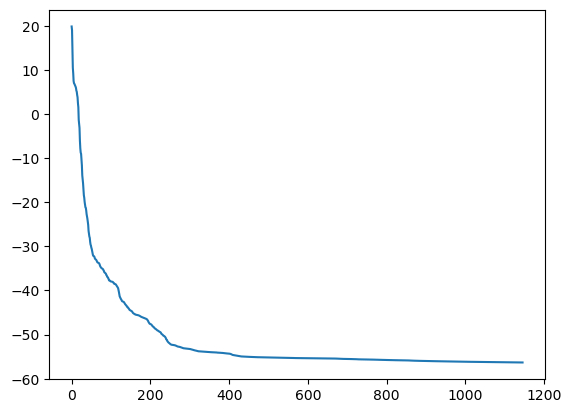

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.5796668616251756e-05  │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 2.86161                 │
├────────────────────────────────────────────────┼───────────┼──────────────────┼───────

In [6]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

ivs = np.linspace(0, max(X[:,0]), nIV).reshape(-1, 1)
iv_ind = np.concatenate((np.ones((halfIV,1 )), np.zeros((halfIV, 1))))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg
m = SparseCMOGP((X, y), exact_target=False, kernel=kern, jitter=1e-6, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.inducing_variable.Z, False)

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)

In [7]:
def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(8, 4))
    Xtest = np.linspace(0, 1, 100)[:, None]
    (line,) = plt.plot(X1, Y1, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y1")

    (line,) = plt.plot(X2, Y2, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y2")
    ivs = m.inducing_variable.Z.numpy() 
    plt.scatter(ivs, np.zeros_like(ivs))
    plt.legend()
    return np.mean((mu - Xtest) ** 2)
 

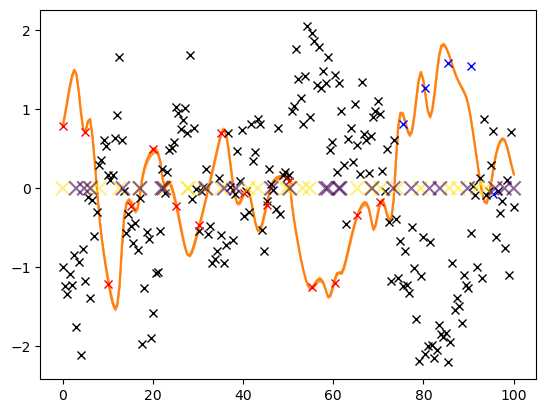

0.11705553857449162

In [8]:
from sklearn.metrics import mean_squared_error
Xall = Xall.reshape(-1, 1)
Xtst = Xtest.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
ymean, yvar = m.predict_y(Xplot)
plt.plot(Xall, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (ymean - 2 * np.sqrt(yvar))[:, 0],
    (ymean + 2 * np.sqrt(yvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs[:,0])*0, marker="x", c=ivs[:,1], zorder=100, s=100, alpha=0.6)
plt.show()

ours_mse = mean_squared_error(ytest, fmean_tst)
ours_mse

### Sparse MOGP with exact target 
If the target is not super big, you can also use the exact target (sometimes, it can technically become inconsistent), so the covariance of the target given source used in the objective is, 
$Q_{t|s} = \begin{bmatrix} K_{tt} + \Lambda_t & Q_{ts} \\ Q_{st} & Q_{ss} + \Lambda_s \end{bmatrix}$

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═══════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value         │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═══════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0           │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0           │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────────┤
│ Spar

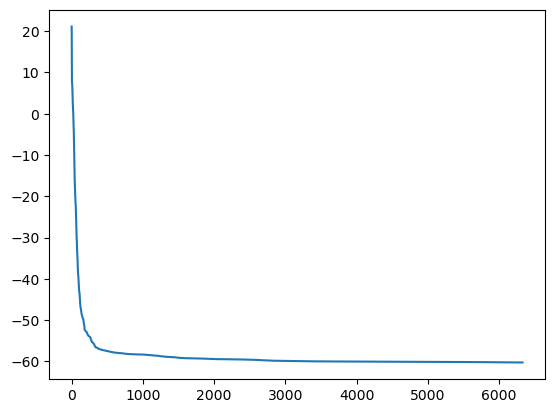

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 2.6413647062665777e-05  │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 6.21094                 │
├────────────────────────────────────────────────┼───────────┼──────────────────┼───────

In [9]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

ivs = np.linspace(0, max(X[:,0]), nIV).reshape(-1, 1)
iv_ind = np.concatenate((np.ones((halfIV,1 )), np.zeros((halfIV, 1))))  # I guess the IPs for the target don't matter here, but this makes the comparison fair.
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg
m = SparseCMOGP((X, y), exact_target=True, kernel=kern, jitter=1e-6, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.inducing_variable.Z, False)

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)

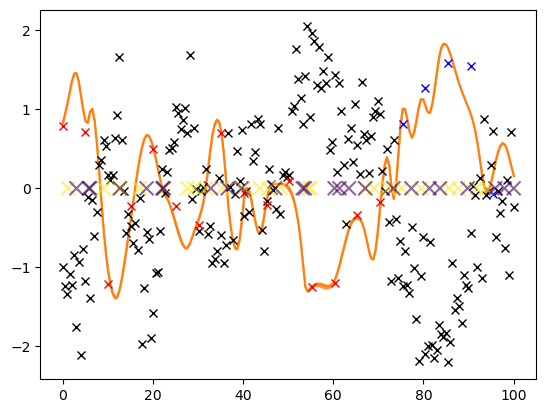

0.11533073494812196

In [10]:
from sklearn.metrics import mean_squared_error
Xall = Xall.reshape(-1, 1)
Xtst = Xtest.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
ymean, yvar = m.predict_y(Xplot)
plt.plot(Xall, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (ymean - 2 * np.sqrt(yvar))[:, 0],
    (ymean + 2 * np.sqrt(yvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs[:,0])*0, marker="x", c=ivs[:,1], zorder=100, s=100, alpha=0.6)
plt.show()

ours_exact_mse = mean_squared_error(ytest, fmean_tst)
ours_exact_mse

### SVGP

I don't think this is technically valid, because the indices (which the coregion kernel needs) of the inducing points are never fixed. 

In [11]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

lik = gpf.likelihoods.SwitchedLikelihood(
    [gpf.likelihoods.Gaussian(), gpf.likelihoods.Gaussian()]
)

ivs = np.linspace(0, max(X[:,0]), nIV).reshape(-1, 1)
iv_ind = np.concatenate((np.ones((halfIV,1 )), np.zeros((halfIV, 1))))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
X = np.vstack((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
y = np.vstack((np.hstack((y1, np.zeros_like(y1))), np.hstack((y2, np.ones_like(y2)))))
# now build the GP model as normal
m = gpf.models.SVGP(kernel=kern, likelihood=lik, num_data=len(X), inducing_variable=ivs)
# gpf.set_trainable(m.inducing_variable.Z, False)

# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    m.training_loss_closure((X, y)),
    m.trainable_variables,
    method="L-BFGS-B",
)

2026-06-10 18:29:36.325243: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-06-10 18:29:36.369579: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 179.10786033043837
        x: [-4.662e-02 -7.257e-01 ... -1.358e+00 -1.959e+00]
      nit: 896
      jac: [ 1.155e-03 -6.065e-03 ... -3.785e-04 -2.351e-04]
     nfev: 930
     njev: 930
 hess_inv: <1433x1433 LbfgsInvHessProduct with dtype=float64>

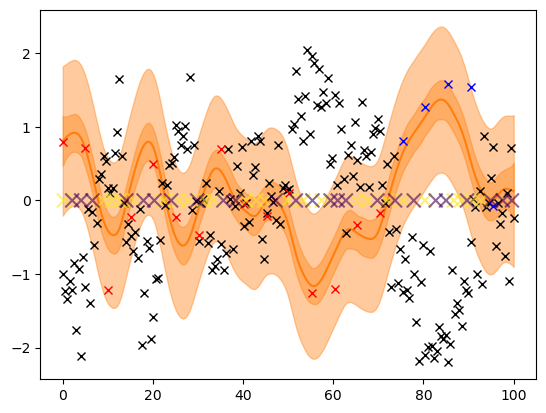

0.22891338885690518

In [12]:
from sklearn.metrics import mean_squared_error
Xall = Xall.reshape(-1, 1)
Xtst = Xtest.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
ymean, yvar = m.predict_y(Xplot)
plt.plot(Xall, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (ymean - 2 * np.sqrt(yvar))[:, 0],
    (ymean + 2 * np.sqrt(yvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs)[:,0]*0, marker="x", c=ivs[:,1], zorder=100, s=100, alpha=0.6)
plt.show()

svgp_mse= mean_squared_error(ytest, fmean_tst)
svgp_mse

### Direct MSE comparison

In [13]:
print("CMOGP\t\t\t\t", cmogp_mse)
print("sCMOGP, approximate target\t", ours_mse)
print("sCMOGP, exact target\t\t", ours_exact_mse)
print("SVGP \t\t\t\t", svgp_mse)

CMOGP				 0.221124179150606
sCMOGP, approximate target	 0.11705553857449162
sCMOGP, exact target		 0.11533073494812196
SVGP 				 0.22891338885690518
